Step Size (h)   | Max |Eigenvalue|   | Stability Status
-------------------------------------------------------
0.01            | 1.0000             | Solution may not be Entirely Stable ;)
0.02            | 1.0002             | Solution may not be Entirely Stable ;)
0.03            | 1.0004             | Solution may not be Entirely Stable ;)
0.05            | 1.0012             | Solution may not be Entirely Stable ;)
0.1             | 1.0050             | Solution may not be Entirely Stable ;)
0.2             | 1.0198             | Solution may not be Entirely Stable ;)
0.3             | 1.0440             | Solution may not be Entirely Stable ;)
0.5             | 1.1180             | Solution may not be Entirely Stable ;)


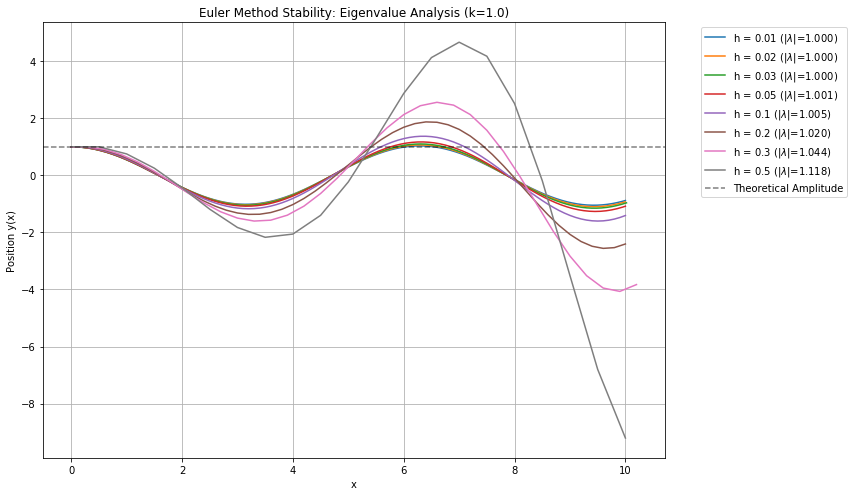

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 1.0
x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(12, 7))

print(f"{'Step Size (h)':<15} | {'Max |Eigenvalue|':<18} | {'Stability Status'}")
print("-" * 55)

for h in h_values:
    # 1. Construct the Coefficient Matrix A
    # y_{n+1} = y_n + h*v_n
    # v_{n+1} = -k*h*y_n + v_n
    A = np.array([[1, h], 
                  [-k*h, 1]])
    
    # 2. Compute Eigenvalues
    eigenvalues = np.linalg.eigvals(A)
    max_eigen_mag = np.max(np.abs(eigenvalues))
    
    # 3. Check Stability
    status = "Solution is Stable" if max_eigen_mag < 1 else "Solution may not be Entirely Stable ;)"
    print(f"{h:<15} | {max_eigen_mag:<18.4f} | {status}")
    
    # 4. Simulate for visualization
    x_vals = np.arange(x_start, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    v_vals = np.zeros(len(x_vals))
    
    y_vals[0] = y_0
    v_vals[0] = v_0
    
    for i in range(1, len(x_vals)):
        y_vals[i] = y_vals[i-1] + h * v_vals[i-1]
        v_vals[i] = v_vals[i-1] + h * (-k * y_vals[i-1])
        
    plt.plot(x_vals, y_vals, label=f'h = {h} ($|\lambda|$={max_eigen_mag:.3f})')

plt.axhline(1, color='black', linestyle='--', alpha=0.5, label='Theoretical Amplitude')
plt.xlabel('x')
plt.ylabel('Position y(x)')
plt.title(f'Euler Method Stability: Eigenvalue Analysis (k={k})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()